<a href="https://colab.research.google.com/github/sohampalav/MyWebPage/blob/main/ML_experiment_5_CE_34.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
# Task 1: Environment Setup and Dataset Acquisition

# 1. Import necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# 2. Upload the dataset
from google.colab import files

uploaded = files.upload()

# 3. Load the uploaded CSV file
df = pd.read_csv("diabetes.csv")

# 4. Assign appropriate column headers
df.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# 5. Print first five records
print("First Five Records:")
print(df.head())

# 6. Print dataset shape
print("\nDataset Shape:")
print(df.shape)

# 7. Print data types
print("\nData Types of All Features:")
print(df.dtypes)

# 8. Print descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

Saving diabetes.csv to diabetes (1).csv
First Five Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Data Types of All Features:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI      

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Distribution:
----------------------------------------
Non-diabetic (0): 500 (65.10%)
Diabetic (1):     268 (34.90%)


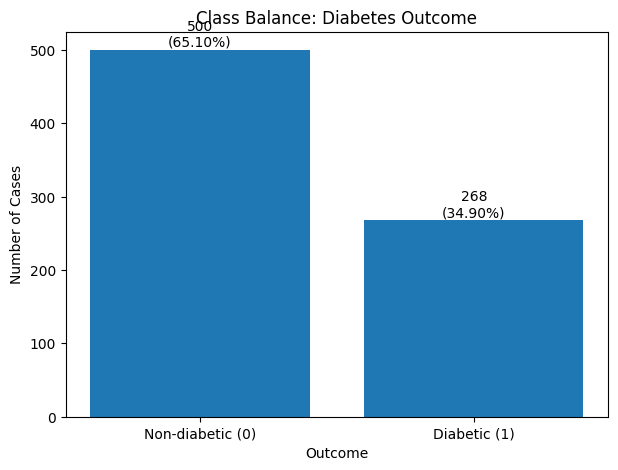

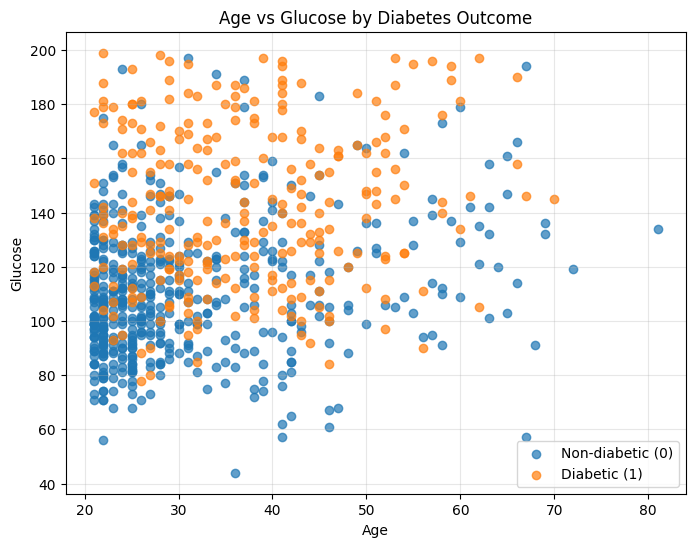

In [ ]:
# Task 2: Exploratory Data Analysis (EDA)

# 1. Calculate absolute count and percentage of each class

class_counts = df["Outcome"].value_counts().sort_index()
class_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("Class Distribution:")
print("-" * 40)

print(f"Non-diabetic (0): {class_counts[0]} "
      f"({class_percentages[0]:.2f}%)")

print(f"Diabetic (1):     {class_counts[1]} "
      f"({class_percentages[1]:.2f}%)")


# Plot class balance using bar chart

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Non-diabetic (0)", "Diabetic (1)"],
    [class_counts[0], class_counts[1]]
)

plt.title("Class Balance: Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Cases")

# Display count and percentage on bars
for bar, count, percentage in zip(
    bars,
    [class_counts[0], class_counts[1]],
    [class_percentages[0], class_percentages[1]]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count}\n({percentage:.2f}%)",
        ha="center"
    )

plt.show()


# 2. Scatter plot of Age against Glucose
# Color-coded according to Outcome

plt.figure(figsize=(8, 6))

for outcome, label in [
    (0, "Non-diabetic (0)"),
    (1, "Diabetic (1)")
]:

    subset = df[df["Outcome"] == outcome]

    plt.scatter(
        subset["Age"],
        subset["Glucose"],
        label=label,
        alpha=0.7
    )

plt.title("Age vs Glucose by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# Task 3: Preprocessing and Handling Missing Values

import numpy as np
import pandas as pd

# Upload the dataset
from google.colab import files

uploaded = files.upload()

# Get the uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)

# Assign column names
df.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# 1. Features where 0 is physically impossible
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Features where 0 is physically impossible:")
print(invalid_features)

# Check number of zero values before replacement
print("\nInvalid 0 values before replacement:")

for feature in invalid_features:
    print(feature, ":", (df[feature] == 0).sum())

# 2. Replace invalid 0 values with NaN
df[invalid_features] = df[invalid_features].replace(0, np.nan)

# Display missing values
print("\nMissing values after replacing 0 with NaN:")
print(df[invalid_features].isnull().sum())

# 3. Impute missing values using median
for feature in invalid_features:
    df[feature] = df[feature].fillna(df[feature].median())

# Check missing values after imputation
print("\nMissing values after median imputation:")
print(df[invalid_features].isnull().sum())

# Final dataset shape
print("\nFinal Dataset Shape:")
print(df.shape)

# Display first five records
print("\nFirst Five Records After Preprocessing:")
print(df.head())

Saving diabetes.csv to diabetes (2).csv
Features where 0 is physically impossible:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Invalid 0 values before replacement:
Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after replacing 0 with NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Final Dataset Shape:
(768, 9)

First Five Records After Preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# Task 4: Stratified Train-Test Splitting

from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)

# First 8 columns = Features
X = df.iloc[:, :8]

# 9th column = Target
y = df.iloc[:, 8]

print("Feature Matrix (X) Shape:", X.shape)
print("Target Vector (y) Shape:", y.shape)

# 2. Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Display shapes
print("\nTraining Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Check class proportions
print("\nClass Distribution in Original Dataset:")
print(y.value_counts(normalize=True) * 100)

print("\nClass Distribution in Training Dataset:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass Distribution in Testing Dataset:")
print(y_test.value_counts(normalize=True) * 100)

Feature Matrix (X) Shape: (768, 8)
Target Vector (y) Shape: (768,)

Training Data:
X_train: (614, 8)
y_train: (614,)

Testing Data:
X_test: (154, 8)
y_test: (154,)

Class Distribution in Original Dataset:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Class Distribution in Training Dataset:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Class Distribution in Testing Dataset:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# Task 5: Custom Bootstrap Sampling Function

import numpy as np

# Custom bootstrap sampling function
def get_bootstrap_sample(X, y):
    # Number of training samples
    N = len(X)

    # Randomly select N indices with replacement
    bootstrap_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[bootstrap_indices].reset_index(drop=True)
    y_bootstrap = y.iloc[bootstrap_indices].reset_index(drop=True)

    return X_bootstrap, y_bootstrap, bootstrap_indices


# Generate bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# Display shapes
print("Original Training Data Shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nBootstrap Sample Shape:")
print("X*:", X_bootstrap.shape)
print("y*:", y_bootstrap.shape)


# Verify duplicate indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicate_indices = unique_indices[counts > 1]

print("\nNumber of unique samples selected:", len(unique_indices))
print("Number of duplicated indices:", len(duplicate_indices))

print("\nSome duplicated original row indices:")
print(duplicate_indices[:10])


# Find Out-of-Bag (OOB) indices
all_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("\nNumber of OOB samples:", len(oob_indices))

print("\nSome OOB original row indices:")
print(oob_indices[:10])

Original Training Data Shape:
X_train: (614, 8)
y_train: (614,)

Bootstrap Sample Shape:
X*: (614, 8)
y*: (614,)

Number of unique samples selected: 398
Number of duplicated indices: 155

Some duplicated original row indices:
[ 0  1  3  6  7  9 12 13 15 16]

Number of OOB samples: 216

Some OOB original row indices:
[ 2 14 22 25 26 29 32 35 36 41]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# Task 6: Growing the Ensemble of Base Classifiers

from sklearn.tree import DecisionTreeClassifier

# 1. Initialize ensemble
B = 50
ensemble = []

# 2. Train B decision trees
for b in range(B):

    # Generate a unique bootstrap sample
    X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model
    model.fit(X_bootstrap, y_bootstrap)

    # Add trained model to ensemble
    ensemble.append(model)

# 3. Verify the ensemble
print("Number of trees in the ensemble:", len(ensemble))

print("\nEnsemble successfully created!")
print("Each tree was trained on a different bootstrap sample.")

Number of trees in the ensemble: 50

Ensemble successfully created!
Each tree was trained on a different bootstrap sample.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# Task 7: Custom Bagging Prediction using Majority Voting

def custom_bagging_predict(ensemble, X_test):

    # Store predictions from all trees
    all_predictions = []

    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert to NumPy array
    all_predictions = np.array(all_predictions)

    # Majority voting
    final_predictions = []

    for i in range(len(X_test)):
        votes = all_predictions[:, i]

        votes_for_0 = np.sum(votes == 0)
        votes_for_1 = np.sum(votes == 1)

        if votes_for_1 > votes_for_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# Generate Bagging predictions
y_pred_bagging = custom_bagging_predict(ensemble, X_test)


# Show first 20 predictions
print("First 20 Bagging Predictions:")
print(y_pred_bagging[:20])

# Show first 20 actual values for comparison
print("\nFirst 20 Actual Values:")
print(y_test.iloc[:20].values)

First 20 Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]

First 20 Actual Values:
[0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

CONFUSION MATRIX - SINGLE DECISION TREE
[[87 13]
 [16 38]]

CONFUSION MATRIX - BAGGING
[[90 10]
 [ 9 45]]


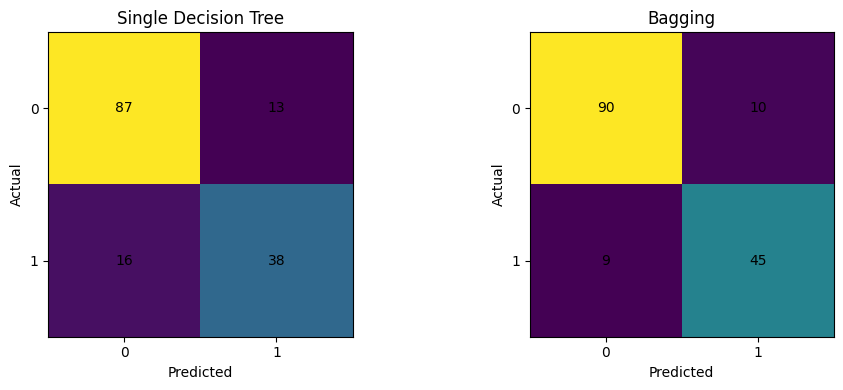


PERFORMANCE COMPARISON
Metric              Single Tree         Bagging
---------------------------------------------
Accuracy        0.8117            0.8766
Precision       0.7451            0.8182
Recall          0.7037            0.8333
F1-Score        0.7238            0.8257


In [ ]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Train a standalone fully grown Decision Tree
# --------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

# Predict using single tree
y_pred_single = single_tree.predict(X_test)


# --------------------------------------------------
# 2. Predict using Custom Bagging Classifier
# --------------------------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# --------------------------------------------------
# 3. Confusion Matrices
# --------------------------------------------------

cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("=" * 50)
print("CONFUSION MATRIX - SINGLE DECISION TREE")
print("=" * 50)
print(cm_single)

print("\n" + "=" * 50)
print("CONFUSION MATRIX - BAGGING")
print("=" * 50)
print(cm_bagging)


# --------------------------------------------------
# Display confusion matrices as plots
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(cm_single)
axes[0].set_title("Single Decision Tree")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_single[i, j],
                     ha="center", va="center")

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])


axes[1].imshow(cm_bagging)
axes[1].set_title("Bagging")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_bagging[i, j],
                     ha="center", va="center")

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. Calculate Performance Metrics
# --------------------------------------------------

# Single Decision Tree
single_accuracy = accuracy_score(y_test, y_pred_single)
single_precision = precision_score(y_test, y_pred_single)
single_recall = recall_score(y_test, y_pred_single)
single_f1 = f1_score(y_test, y_pred_single)


# Bagging
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging)
bagging_recall = recall_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)


# --------------------------------------------------
# 5. Print comparison
# --------------------------------------------------

print("\n" + "=" * 65)
print("PERFORMANCE COMPARISON")
print("=" * 65)

print(f"{'Metric':<15} {'Single Tree':>15} {'Bagging':>15}")
print("-" * 45)

print(f"{'Accuracy':<15} "
      f"{single_accuracy:.4f}{'':>11} "
      f"{bagging_accuracy:.4f}")

print(f"{'Precision':<15} "
      f"{single_precision:.4f}{'':>11} "
      f"{bagging_precision:.4f}")

print(f"{'Recall':<15} "
      f"{single_recall:.4f}{'':>11} "
      f"{bagging_recall:.4f}")

print(f"{'F1-Score':<15} "
      f"{single_f1:.4f}{'':>11} "
      f"{bagging_f1:.4f}")

print("=" * 65)

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

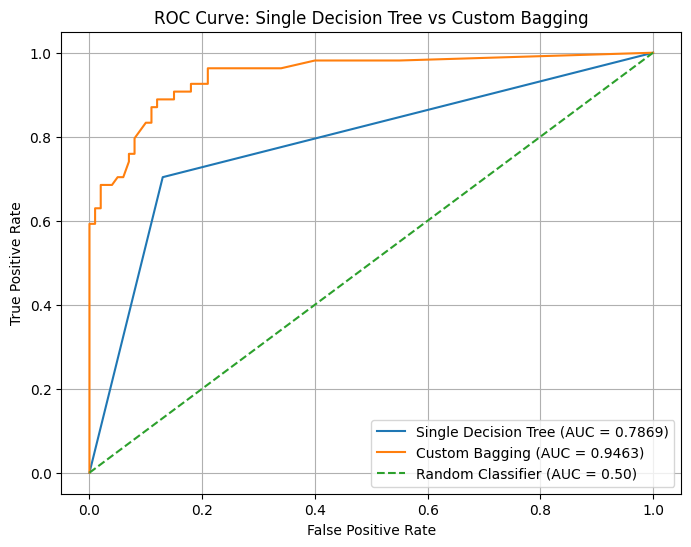

ROC-AUC COMPARISON
Single Decision Tree AUC : 0.7869
Custom Bagging AUC       : 0.9463

AUC Improvement          : 0.1594


In [ ]:
# Task 9: ROC-AUC Analysis and Curve Visualization

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Single Decision Tree Probability Predictions
# --------------------------------------------------

# Probability of class 1 (diabetic)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# --------------------------------------------------
# 2. Custom Bagging Probability Predictions
# --------------------------------------------------

# Store probability predictions from all trees
all_probabilities = []

for model in ensemble:
    probabilities = model.predict_proba(X_test)[:, 1]
    all_probabilities.append(probabilities)

# Convert to NumPy array
all_probabilities = np.array(all_probabilities)

# Average probabilities across all 50 trees
y_prob_bagging = np.mean(all_probabilities, axis=0)


# --------------------------------------------------
# 3. Calculate ROC Curve
# --------------------------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# --------------------------------------------------
# 4. Calculate AUC
# --------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# --------------------------------------------------
# 5. Plot both ROC curves
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.4f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.50)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Decision Tree vs Custom Bagging")

plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------------
# 6. Print AUC comparison
# --------------------------------------------------

print("=" * 55)
print("ROC-AUC COMPARISON")
print("=" * 55)

print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Custom Bagging AUC       : {auc_bagging:.4f}")

print(f"\nAUC Improvement          : "
      f"{auc_bagging - auc_single:.4f}")

print("=" * 55)

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

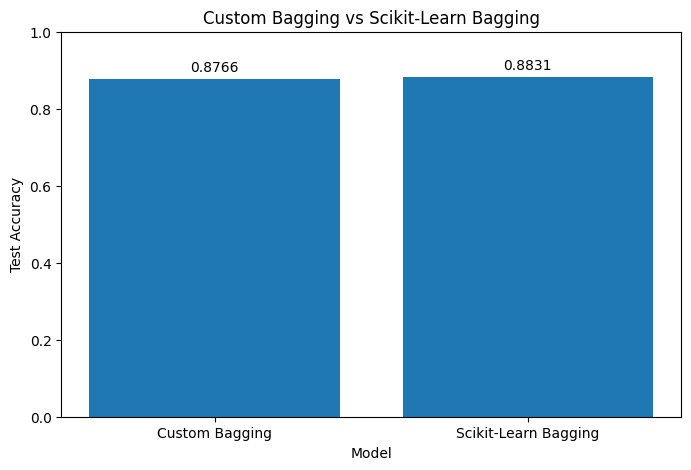

In [ ]:
# Task 10: Accuracy Comparison Chart

import matplotlib.pyplot as plt

models = [
    "Custom Bagging",
    "Scikit-Learn Bagging"
]

accuracies = [
    accuracy_custom,
    accuracy_sklearn
]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.title("Custom Bagging vs Scikit-Learn Bagging")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

# Display accuracy values on bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{accuracy:.4f}",
        ha="center"
    )

plt.show()

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?